<a href="https://colab.research.google.com/github/sandeepgangaram/neural-nets/blob/master/makemor/mlp3_wavenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt


--2026-03-22 09:15:51--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.1’

names.txt.1         100%[===================>] 222.80K  --.-KB/s    in 0.003s  

2026-03-22 09:15:51 (63.7 MB/s) - ‘names.txt.1’ saved [228145/228145]



In [56]:
words = open('./names.txt','r').read().splitlines()

words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [57]:
len(words)

32033

In [58]:
from IPython.core.crashhandler import crash_handler_lite
#build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {char:i+1 for i,char in enumerate(chars)}
stoi['.'] = 0
itos = {i: char for char, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)
# itos

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [136]:
block_size = 8 #context length - characters to predict next character

# build the dataset
def build_dataset(words):
  X, Y = [],[]

  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context),'--->', itos[ix])
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  # print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])     #training set 80% - train parameters
Xdev, Ydev = build_dataset(words[n1:n2]) #dev/validation set 10% - train hyperparameters
Xte, Yte = build_dataset(words[n2:])     #test set 10%


In [151]:
# Deeper Network

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) /fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x@self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    #parmeters (trained with bckprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    #buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self,x):
    #calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim=(0,1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    #update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
        self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, n_embeddings, embedding_dim):
    self.weight = torch.randn((n_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self,n):
    self.n = n

  def __call__(self,x):
    B,T,C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self,layers):
    self.layers = layers

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [152]:
torch.manual_seed(42)

In [153]:
n_embed = 24 #the dimensionality of the character embedding vectors
n_hidden = 128 #the number of neurons in the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2), Linear(n_embed*2, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

76579


In [140]:
Xtr.shape
ix = torch.randint(0, Xtr.shape[0],(4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 14,  1, 10, 12],
        [ 0,  0,  0,  0,  0,  0, 11,  1],
        [ 0,  0,  0,  0,  8,  1, 18, 15],
        [ 0,  0,  0,  0,  0,  0, 10,  1]])

In [141]:
for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [129]:
e = torch.randn(32,4,68)
emean = e.mean((0,1),keepdim=True) #torch.Size([1, 4, 68])
evar = e.var((0,1),keepdim=True)#torch.Size([1, 4, 68])
ehat = (e-emean)/torch.sqrt(evar+1e-5) #torch.Size([32, 4, 68])
emean.shape, evar.shape, ehat.shape

(torch.Size([1, 1, 68]), torch.Size([1, 1, 68]), torch.Size([32, 4, 68]))

In [142]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [84]:
model.layers[0].out.shape #otuput of Embedding layer

torch.Size([4, 8, 10])

In [85]:
model.layers[1].out.shape #output of Flatten layer

torch.Size([4, 80])

In [86]:
model.layers[2].out.shape #output of Linear layer

torch.Size([4, 200])

In [91]:
(torch.randn(4,4,20) @ torch.randn(20,200)).shape

torch.Size([4, 4, 200])

In [94]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [121]:
e = torch.randn(4,8,10) #Goal - want (4,4,20) where consecutive 10-d vectors get concatenated
# e.view(4,-1,20).shape
(e.view(4,-1,20) == torch.cat([e[:,::2,:],e[:,1::2,:]],dim=2)).all()

tensor(True)

In [154]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  xi = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[xi], Ytr[xi] #batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 == 0:
    print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # break


      0/ 200000 : 4.2059
  10000/ 200000 : 2.1284
  20000/ 200000 : 2.0120
  30000/ 200000 : 1.7547
  40000/ 200000 : 2.0424
  50000/ 200000 : 2.2117
  60000/ 200000 : 2.3595
  70000/ 200000 : 1.6436
  80000/ 200000 : 1.6880
  90000/ 200000 : 1.7367
 100000/ 200000 : 2.0877
 110000/ 200000 : 1.8207
 120000/ 200000 : 1.8329
 130000/ 200000 : 1.7120
 140000/ 200000 : 1.7904
 150000/ 200000 : 1.9944
 160000/ 200000 : 1.9370
 170000/ 200000 : 1.8578
 180000/ 200000 : 1.9571
 190000/ 200000 : 1.5844


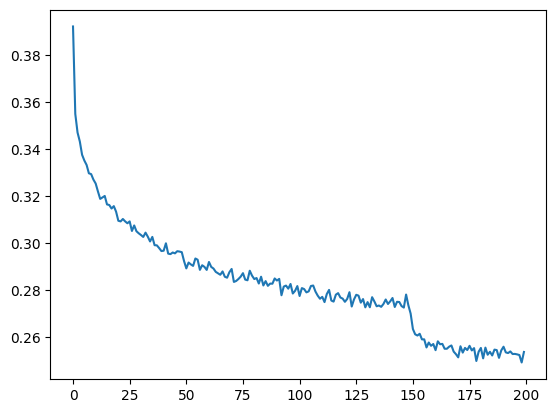

In [155]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [156]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [157]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits=model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7650569677352905
val 1.9963109493255615


In [ ]:
# #before
# train 1.9178067445755005
# val 2.026582717895508

# #bug fix batch norm
# train 1.9162064790725708
# val 2.029345750808716

# scale network - n_embed = 24 #n_hidden = 128
# train 1.7650569677352905
# val 1.9963109493255615

In [158]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      logits = model([torch.tensor([context])]) # (1,block_size,d)
      # sample from the distribution
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
amoria.
khyri.
shreet.
khalani.
emmah.
braden.
artier.
eilah.
martice.
ihvik.
legy.
dhamond.
miquinn.
shlomon.
jadia.
waverly.
jaryn.
karmelli.
sabier.


/tmp/ipykernel_2310/38859505.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  self.out = self.weight[IX]


In [161]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

........ --> s
.......s --> u
......su --> l
.....sul --> e
....sule --> m
...sulem --> a
..sulema --> n
.suleman --> .


In [165]:
#forward a single example
logits = model(Xtr[[7]])
print(logits.shape)

torch.Size([1, 27])


In [166]:
#forward all of them
logits = torch.zeros((8,27))
for i in range(8):
  logits[i] = model(Xtr[[i]])
print(logits.shape)


torch.Size([8, 27])


In [ ]:
# convolution is a for loop
# allows us to forward Linear layers effeciently in space